In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

In [20]:
# Load and clean the data
data = pd.read_csv("1429_1.csv")
data["name"] = data["name"].fillna("Unknown Product")

product_list = data["name"].astype(str).to_list()

/tmp/ipykernel_4669/1387481102.py:2: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("1429_1.csv")


In [21]:
# Embed cleaned strings
embedder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedder.encode(product_list)

# Perform K-Means Clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# Store results in dataframe for inspection
results = pd.DataFrame({
    "name": product_list,
    "cluster": cluster_labels
})

# Check the clusters
for i in range(num_clusters):
    print(f"\n--- Cluster {i} Sample Items ---")
    print(results[results["cluster"] == i]["name"].head(3).values)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Cluster 0 Sample Items ---
['All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta'
 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta'
 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta']

--- Cluster 1 Sample Items ---
['Unknown Product' 'Unknown Product' 'Unknown Product']

--- Cluster 2 Sample Items ---
['Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers,,'
 'Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers,,'
 'Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers,,']

--- Cluster 3 Sample Items ---
['Echo (White),,,\r\nEcho (White),,,' 'Echo (White),,,\r\nEcho (White),,,'
 'Echo (White),,,\r\nEcho (White),,,']

--- Cluster 4 Sample Ite

In [22]:
name_to_cluster = dict(zip(
    results["name"].astype(str).str.lower(),
    results["cluster"]
))

# Mapping logic
data["temp_id_key"] = data["name"].astype(str).str.lower()

# Find matches
data["cluster_id"] = data["temp_id_key"].map(name_to_cluster)

# Cleanup
data = data.drop(columns=["temp_id_key"])

print(data[["name", "cluster_id"]].head())

                                                name  cluster_id
0  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...           0
1  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...           0
2  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...           0
3  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...           0
4  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...           0


In [23]:
def plot_silhouette(X, cluster_labels):
    n_clusters = len(np.unique(cluster_labels))

    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(10, 7)
    ax1.set_xlim([-0.1, 1])

    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    silhouette_avg = silhouette_score(X, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is: {silhouette_avg:.3f}")

    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.show()

For n_clusters = 5, the average silhouette_score is: 0.770


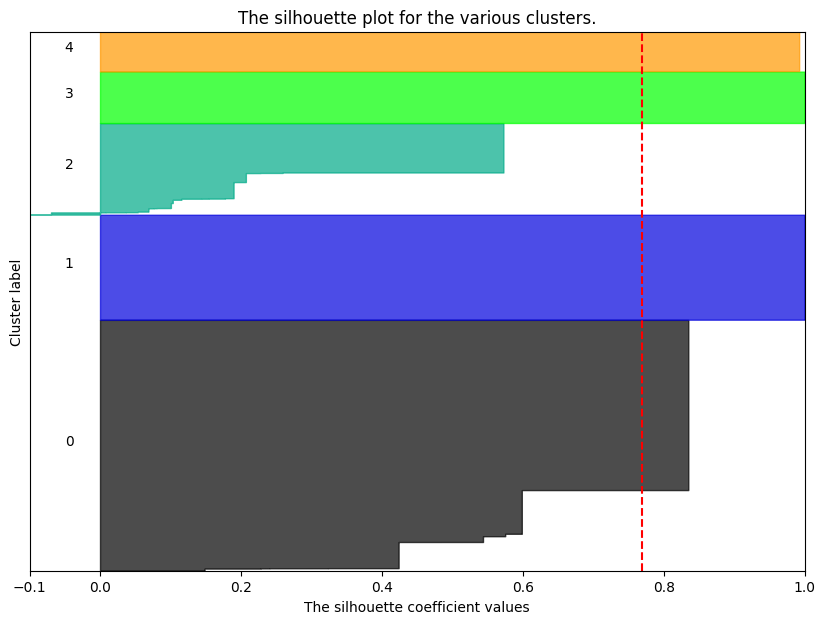

In [24]:
plot_silhouette(embeddings, cluster_labels)

In [26]:
import re

def distill_cluster_v2(results_df, cluster_id):
    unique_names = results_df[results_df["cluster"] == cluster_id]["name"].unique()

    clean_set = set()
    for name in unique_names:
        clean_name = re.sub(r"[^a-zA-Z0-9\s]", " ", name)
        clean_name = " ".join(clean_name.split()[:10]).lower()
        clean_set.add(clean_name)

    # Return up to 10 unique variations
    return "\n- ".join(list(clean_set)[:10])

print(distill_cluster_v2(results, 3.0))

echo white echo white
- echo black echo black


In [31]:
import os
from dotenv import load_dotenv
from openai import OpenAI
from google.colab import userdata
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

# load_dotenv()
client = OpenAI(api_key=OPENAI_API_KEY)


def get_professional_label(distilled_text):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a retail data expert. "
                "Your task is to provide a single, professional 2-3 word category "
                "name that summarizes a list of products. "
                "Avoid being too specific (e.g., use 'Tableware' instead of 'Plates'). "
                "Return ONLY the category name."},
                {"role": "user", "content": f"Product List:\n{distilled_text}"}
            ],
            temperature=0
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return "Uncategorized"

print(get_professional_label(distill_cluster_v2(results, 1.0)))

General Merchandise


In [32]:
# Create mapping for clustering labels
c_labels_map = {}
existing_labels = set()
unique_clusters = [c for c in data["cluster_id"].unique() if pd.notna(c)]

for cluster in unique_clusters:
    cluster_key = int(cluster)
    label = get_professional_label(distill_cluster_v2(results, cluster_key))
    if label in existing_labels:
        label = f"{label} (Group {cluster_key})"

    c_labels_map[cluster_key] = label
    existing_labels.add(label)

In [34]:
data["cluster"] = data["cluster_id"].map(c_labels_map).fillna("Miscellaneous")
data["cluster"].unique()

array(['Tablets', 'Electronics & Accessories', 'Streaming Devices',
       'Echo Products', 'General Merchandise'], dtype=object)